In [1]:
import numpy as np

In [2]:
class Node():
    def __init__(self,feature=None,threshold=None,left=None,right=None,value=None):
        self.value = value
        self.left = left
        self.right = right
        self.threshold = threshold
        self.feature = feature
    def is_leaf(self):
        return self.value is not None

In [5]:
class Tree():
    def __init__(self,max_depth=20):
        self.max_depth = max_depth
    def gini(self,y):
        if len(y)==0:
            return 0
        _,counts = np.unique(y,return_counts=True)
        probs = counts/len(y)
        return 1-np.sum(probs**2)
    def split(self,X,threshold):
        le_ind = np.argwhere(X<=threshold).flatten()
        gt_ind = np.argwhere(X>threshold).flatten()
        return le_ind,gt_ind
    def info_gain(self,X_col,y,threshold):
        y_n = len(y)
        y_gini = self.gini(y)
        le_ind,gt_ind = self.split(X_col,threshold)
        le_n = len(le_ind)
        gt_n = len(gt_ind)
        if le_n == 0 or gt_n == 0:
            return 0
        le = self.gini(y[le_ind])
        gt = self.gini(y[gt_ind])
        child_gini = (le_n/y_n)*le+(gt_n/y_n)*gt
        return y_gini-child_gini
    def best_split(self,X,y,features):
        best_gain = -1
        split_index = split_threshold = None
        for f in features:
            Xcol = X[:,f]
            uniq = np.unique(Xcol)
            thresholds = (uniq[:-1]+uniq[1:])/2
            for t in thresholds:
                gain = self.info_gain(Xcol,y,t)
                if gain>best_gain:
                    best_gain = gain
                    split_index = f
                    split_threshold = t
        return split_index,split_threshold
    def most_common_label(self,y):
        if len(y)==0: 
            return None
        vals, count = np.unique(y,return_counts=True)
        return vals[np.argmax(count)]
    def grow(self,X,y,features,depth=0):
        n_features = len(features)
        n_samples = X.shape[0]
        n_labels = len(np.unique(y))
        if (depth>=self.max_depth or n_features==1 or n_samples==0 or n_labels==1):
            val = value=self.most_common_label(y)
            return Node(value = val)
        best_feat,best_thresh = self.best_split(X,y,features)
        if best_feat==None or best_thresh==None:
            val = value=self.most_common_label(y)
            return Node(value = val)
        left_ind,right_ind = self.split(X[:,best_feat],best_thresh)
        left = self.grow(X[left_ind,:],y[left_ind],features,depth+1)
        right = self.grow(X[right_ind,:],y[right_ind],features,depth+1)
        return Node(best_feat,best_thresh,left,right)
    def traverse(self,x,node):
        if node.is_leaf():
            return node.value
        if x[node.feature]<=node.threshold:
            return self.traverse(x,node.left)
        else:
            return self.traverse(x,node.right)
    def fit(self,X,y):
        self.n_features = X.shape[1]
        feat = list(range(self.n_features))
        self.root = self.grow(X,y,feat)
    def predict(self,X):
        return np.array([self.traverse(x,self.root) for x in X])

Generating Spiral...
Plotting...


<module 'matplotlib.pyplot' from 'C:\\Users\\Rishee Keshavan\\anaconda3\\envs\\tf_env\\lib\\site-packages\\matplotlib\\pyplot.py'>

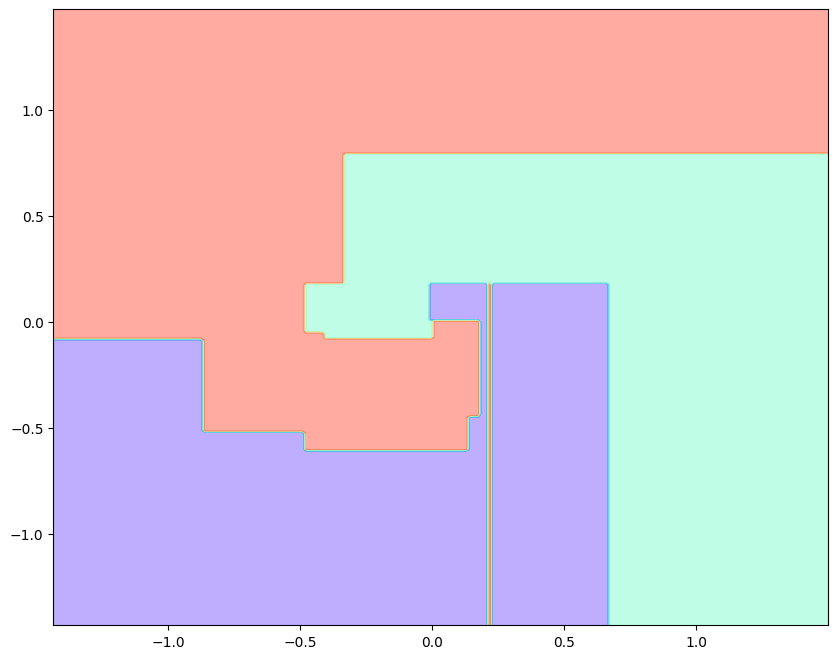

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. SPIRAL DATA GENERATOR ---
def generate_spiral_data(points, classes):
    X = np.zeros((points*classes, 2))
    y = np.zeros(points*classes, dtype='uint8')
    for j in range(classes):
        ix = range(points*j, points*(j+1))
        r = np.linspace(0.0, 1, points) # radius
        t = np.linspace(j*4, (j+1)*4, points) + np.random.randn(points)*0.2 # theta
        X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
        y[ix] = j
    return X, y

print("Generating Spiral...")
X, y = generate_spiral_data(points=200, classes=3)

# --- 2. TRAIN (Deep Tree) ---
# We need a deep tree to capture the spiral arms
clf = Tree(max_depth=50) 
clf.fit(X, y)

# --- 3. VISUALIZE ---
print("Plotting...")
plt.figure(figsize=(10, 8))

# Meshgrid for background color
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf.predict(grid)
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.4, cmap='rainbow')
plt

Training on 1437 images with 64 pixels each...

Test Accuracy: 86.39%
------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92        33
           1       0.91      0.75      0.82        28
           2       0.89      0.76      0.82        33
           3       0.81      0.88      0.85        34
           4       0.82      0.91      0.87        46
           5       0.94      0.94      0.94        47
           6       0.83      0.97      0.89        35
           7       0.86      0.88      0.87        34
           8       0.81      0.70      0.75        30
           9       0.83      0.88      0.85        40

    accuracy                           0.86       360
   macro avg       0.87      0.85      0.86       360
weighted avg       0.87      0.86      0.86       360



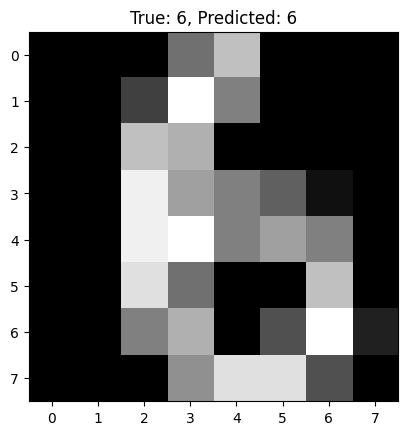

In [23]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Load Data
digits = load_digits()
X = digits.data  # Shape (1797, 64)
y = digits.target # 10 classes

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train
print(f"Training on {X_train.shape[0]} images with {X_train.shape[1]} pixels each...")
clf = Tree(max_depth=25)
clf.fit(X_train, y_train)

# 4. Evaluate
y_pred = clf.predict(X_test)
accuracy = np.mean(y_test == y_pred)

print(f"\nTest Accuracy: {accuracy*100:.2f}%")
print("-" * 30)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Sanity Check (Visualize one prediction)
plt.imshow(X_test[0].reshape(8,8), cmap='gray')
plt.title(f"True: {y_test[0]}, Predicted: {y_pred[0]}")
plt.show()